<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS06/JS06_Tugas_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. Buatlah model SVM dengan menggunakan data voice.csv dengan ketentuan,

a. Split data dengan rasio 70:30 dan 80:20 untuk setiap model yang akan dibangun.

- Gunakan model dengan kernel linier.

- Gunakan model dengan kernel polynomial.

- Gunakan model dengan kernel RBF.

b. Tabulasikan performansi setiap split dan kernel berdasarkan metrik akurasi.


1. Import library

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

2. Load dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving voice (1).csv to voice (1).csv


In [3]:
data = pd.read_csv("voice (1).csv")

data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


3. Encoding Data

In [4]:
# Encoding data label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['label'] = le.fit_transform(data['label'])

data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


4. Pisahkan Fitur dan Target

In [6]:
# Memisahkan fitur dan target
X = data.drop('label', axis=1)
y = data['label']

print("Data fitur:")
display(X.head())

print("Data target:")
display(y.head())

Data fitur:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274


Data target:


,label
0,1
1,1
2,1
3,1
4,1


5. Buat model SVM untuk semua split dan kernel

In [7]:
hasil = []

for split, test_size in [("70:30", 0.30), ("80:20", 0.20)]:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    for kernel in ["linear", "poly", "rbf"]:

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel=kernel))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        hasil.append({
            "Split": split,
            "Kernel": kernel,
            "Akurasi": accuracy
        })

6. Tabulasikan hasil

In [8]:
hasil_df = pd.DataFrame(hasil)

hasil_df["Akurasi (%)"] = hasil_df["Akurasi"] * 100

hasil_df = hasil_df.drop("Akurasi", axis=1)

hasil_df

,Split,Kernel,Akurasi (%)
0,70:30,linear,97.896951
1,70:30,poly,96.004206
2,70:30,rbf,98.317560
3,80:20,linear,97.476341
4,80:20,poly,95.583596
5,80:20,rbf,98.264984



2. Gunakan data pada praktikum 5 untuk membuat model klasifikasi siang dan malam menggunakan SVM dengan kernel RBF menggunakan fitur histrogram. Gunakan rasio 80:20. Anda dapat bereksperimen dengan hyperparameter tunning dari kernel RBF. Catat performansi akurasinya!

1. Import Library

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

2. Load Dataset

In [10]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
train_dir = "/content/drive/MyDrive/images/images/training/"
test_dir = "/content/drive/MyDrive/images/images/test/"

3. Load Gambar


In [15]:
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []

    for folder in p.glob("*"):
        if folder.is_dir():

            label = folder.name

            for file in folder.glob("*.jpg"):
                img = cv2.imread(str(file))

                if img is not None:
                    img_list.append((img, label))

    return img_list

In [16]:
train_data = load_dataset(train_dir)
test_data = load_dataset(test_dir)

print("Jumlah data training:", len(train_data))
print("Jumlah data testing :", len(test_data))

Jumlah data training: 240
Jumlah data testing : 160


4. Gabungkan data

In [17]:
data = train_data + test_data

print("Total data:", len(data))

Total data: 400


In [18]:
# Pisahkan gambar dan label
images = [item[0] for item in data]
labels = [item[1] for item in data]

print("Jumlah gambar:", len(images))
print("Jumlah label :", len(labels))

Jumlah gambar: 400
Jumlah label : 400


5. Membuat fitur histogram

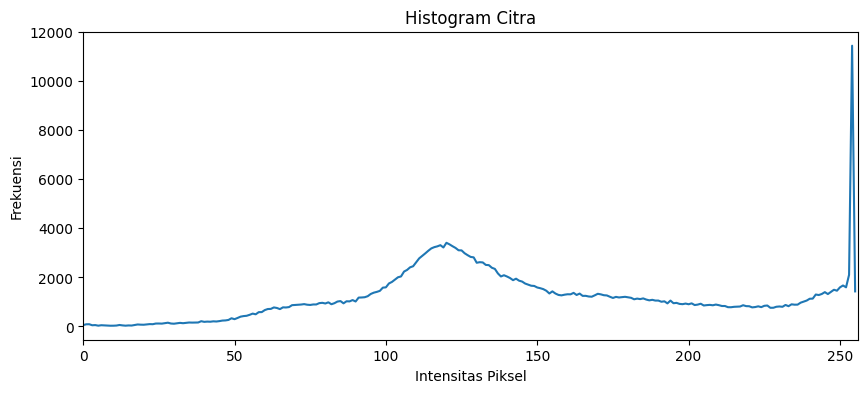

In [35]:
# Ambil satu gambar
img = images[0]

# Ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Hitung histogram
hist = cv2.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
)

# Tampilkan histogram
plt.figure(figsize=(10, 4))
plt.plot(hist)
plt.title("Histogram Citra")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.xlim([0, 256])
plt.show()

In [23]:
# Kemudian ekstrak fitur dari semua gambar:
X = np.array([extract_histogram(img) for img in images])
y = np.array(labels)

print("Ukuran fitur:", X.shape)
print("Ukuran target:", y.shape)

Ukuran fitur: (400, 256)
Ukuran target: (400,)


6. Split data 80:20

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 320
Data testing : 80


7. Membuat SVM RBF

In [25]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [27]:
# Prediksi
y_pred = model.predict(X_test)

# Hitung akurasi:
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi SVM RBF:", accuracy * 100, "%")

Akurasi SVM RBF: 98.75 %


8. Hyperparameter Tuning

In [28]:
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

In [29]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [31]:
# Lihat Parameter Terbaik
print("Parameter terbaik:")
print(grid_search.best_params_)

# Lihat skor cross-validation:
print("Akurasi terbaik saat tuning:",
      grid_search.best_score_ * 100, "%")

Parameter terbaik:
{'svm__C': 1, 'svm__gamma': 0.01}
Akurasi terbaik saat tuning: 98.75 %


9. Evaluasi model terbaik

In [33]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi pada data testing:",
      accuracy * 100, "%")

print(classification_report(y_test, y_pred))

Akurasi pada data testing: 100.0 %
              precision    recall  f1-score   support

         day       1.00      1.00      1.00        40
       night       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



10. Buat tabel hasil

In [34]:
hasil = pd.DataFrame({
    "Model": ["SVM RBF"],
    "Split": ["80:20"],
    "C": [grid_search.best_params_["svm__C"]],
    "Gamma": [grid_search.best_params_["svm__gamma"]],
    "Akurasi": [accuracy * 100]
})

hasil

,Model,Split,C,Gamma,Akurasi
0,SVM RBF,80:20,1,0.01,100.0
